<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_5d_mlp_parameterization_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Five-player Cournot: MLP architecture and tangent-bundle sweep

Run all cells in Colab. This notebook is self-contained: it needs PyTorch, NumPy, and Matplotlib, and does not clone a repository. It sweeps **27 combinations**:

- Hidden width: **16, 32, 64**.
- Hidden depth: **2, 4, 8** (number of hidden linear/activation pairs).
- Selected tangent parameters: **32, 64, 128**.

The baseline **width 16 / depth 2 / bundle 128** is highlighted. Every run starts from the same 3,000 uniform initial particles, uses the same physical time grid, and initializes the residual tanh MLP to the identity by zeroing its final linear layer. The method evolves parameters and accumulated particle values separately, as in the earlier notebook; it does not replace particles by the updated network output.

For each architecture, the model seed is reset before every bundle-size run. The parameter-index generator is also reset: the 32-, 64-, and 128-coordinate subsets are nested prefixes of the same random permutation at each step. Architectures have different parameter spaces, so their subsets are not directly identical.

The requested figures are:

1. Relative projection-error trajectories: nine architecture panels, three bundle-size curves per panel.
2. Alpha-norm trajectories with the same layout.
3. **All 27 raw condition-number trajectories on one axes.**

Additional diagnostics check the least-squares arithmetic, rank truncation, and agreement with a same-step direct Euler reference. An optional baseline step-halving experiment examines time discretization. A single seed can identify mechanisms, but should be repeated with other seeds before concluding one architecture is consistently best.

In [1]:
from pathlib import Path
from itertools import product
import csv
import json
import time
import shutil

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FormatStrFormatter, SymmetricalLogLocator
import torch
from torch import nn
from torch.func import functional_call, jacrev, vmap

torch.set_num_threads(min(4, torch.get_num_threads()))

In [2]:
WIDTHS = (16, 32, 64)
DEPTHS = (2, 4, 8)
BUNDLE_SIZES = (32, 64, 128)
CONFIGURATIONS = list(product(WIDTHS, DEPTHS, BUNDLE_SIZES))
BASELINE = (16, 2, 128)

SEED = 0
BASIS_SEED = SEED + 1
DIM = 5
N_PARTICLES = 3000
H = 0.005
T_FINAL = 2.0
COURNOT_B = 2.0
COURNOT_MU = 7 / 4
DTYPE = torch.float64
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SVD_RTOL = 1e-6
JACOBIAN_CHUNK = 128

# These checks inspect the same J and velocity; they never change an update.
CPU_SOLVER_AUDIT = True
AUDIT_TIMES = (0.0, 0.5, 1.0, 1.5)
AUDIT_RTOLS = (1e-4, 1e-6, 1e-8, 1e-10)

# Optional additional run of ONLY the highlighted baseline at H/2.
RUN_BASELINE_STEP_CHECK = False

OUTPUT_ROOT = Path('/content') if Path('/content').is_dir() else Path.cwd()
RUN_TAG = time.strftime('%Y%m%d-%H%M%S')
OUTPUT_DIR = OUTPUT_ROOT / f'cournot_mlp_sweep_seed{SEED}_{RUN_TAG}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'{len(CONFIGURATIONS)} combinations; device={DEVICE}; dtype={DTYPE}')
print(f'N={N_PARTICLES}, H={H}, final time={T_FINAL}; output: {OUTPUT_DIR}')

27 combinations; device=cuda; dtype=torch.float64
N=3000, H=0.005, final time=2.0; output: /content/cournot_mlp_sweep_seed0_20260910-020027


## Method and diagnostic definitions

The physical velocity is
$$F_i(x)=2b\left(\max\{\mu s_i(1-s_i),0\}-x_i\right),\qquad s_i=\sum_{j\ne i}x_j.$$
For the selected parameter coordinates, form $J_k\in\mathbb R^{5N\times m}$ at the **fixed initial labels** $z$. Write $A_k=J_k/\sqrt N$ and $y_k=\operatorname{vec}(F(x_k))/\sqrt N$.

The truncated SVD keeps $s_j>\texttt{SVD\_RTOL}\,s_{\max}$. Its coefficients update both states:
$$\alpha_k=V_r\Sigma_r^{-1}U_r^Ty_k,\qquad
\theta_{k+1}[S_k]=\theta_k[S_k]+h_k\alpha_k,\qquad
x_{k+1}=x_k+h_k\operatorname{reshape}(J_k\alpha_k).$$

- **Relative projection error:** $\|J_k\alpha_k-\operatorname{vec}F(x_k)\|_2/\|F(x_k)\|_2$.
- **Alpha norm:** $\|\alpha_k\|_2$. It is parameterization-dependent; the relative parameter-step norm is also saved.
- **Raw condition number:** $s_{\max}/s_{\min}$ before truncation. Zero minimum means infinity; a tiny positive value is not clipped. Numerical roundoff can make a rank-deficient matrix appear to have a very large finite ratio.
- **Effective condition number:** largest/smallest *retained* singular values. This is the spectrum the solver actually uses.
- **Solver reconstruction discrepancy:** $\|A_k\alpha_k-U_rU_r^Ty_k\|_2/\|y_k\|_2$. This checks the solved velocity against the SVD's own orthogonal projection.
- **Retained-space orthogonality:** $\|U_r^T(A_k\alpha_k-y_k)\|_2/\|y_k\|_2$. Truncated directions are deliberately excluded from this check.

No artificial denominator floor is used for stored relative errors: $0/0$ is recorded as zero when both norms vanish; nonzero/zero is infinity. Zero retained rank produces $\alpha=0$ and is recorded, rather than treated as a solver crash.

Zero-output initialization makes all earlier-layer Jacobian columns exactly zero initially. Larger networks have a smaller fraction of output-layer coordinates, so a fixed-size random bundle may initially contain very few active columns. The notebook records these counts and the retained rank. A large **raw** condition number alone therefore does not show that the SVD solve is wrong.

In [3]:
class ResidualMLPMap(nn.Module):
    def __init__(self, width, depth):
        super().__init__()
        layers = []
        d_in = DIM
        for _ in range(depth):
            layers.extend((nn.Linear(d_in, width, dtype=DTYPE), nn.Tanh()))
            d_in = width
        layers.append(nn.Linear(d_in, DIM, dtype=DTYPE))
        self.net = nn.Sequential(*layers)
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, labels):
        return labels + self.net(labels)


def flatten_model(model):
    params = list(model.named_parameters())
    structure = [(name, tuple(p.shape), p.numel()) for name, p in params]
    theta = torch.cat([p.detach().reshape(-1).clone() for _, p in params])
    return theta, structure


def selected_jacobian(theta, selected, labels, model, structure):
    frozen = theta.detach()
    theta_selected = frozen[selected].clone()

    def one(theta_s, label):
        full = frozen.index_copy(0, selected, theta_s)
        params, offset = {}, 0
        for name, shape, size in structure:
            params[name] = full[offset:offset + size].reshape(shape)
            offset += size
        return functional_call(model, params, (label.unsqueeze(0),)).squeeze(0)

    batched_jacobian = vmap(jacrev(one, argnums=0), in_dims=(None, 0))
    chunks = []
    for start in range(0, labels.shape[0], JACOBIAN_CHUNK):
        chunk = batched_jacobian(theta_selected, labels[start:start + JACOBIAN_CHUNK])
        chunks.append(chunk.detach())
    return torch.cat(chunks).reshape(labels.shape[0] * DIM, selected.numel())


def game_velocity(x):
    rivals = x.sum(dim=-1, keepdim=True) - x
    best_response = (COURNOT_MU * rivals * (1 - rivals)).clamp_min(0.0)
    return 2 * COURNOT_B * (best_response - x)


def ratio(numerator, denominator):
    numerator, denominator = float(numerator), float(denominator)
    if denominator == 0:
        return 0.0 if numerator == 0 else np.inf
    return numerator / denominator


def truncated_svd_solve(U, s, Vh, target, rtol):
    keep = s > rtol * s[0]
    if keep.any():
        coordinates = U[:, keep].T @ target
        alpha = Vh[keep].T @ (coordinates / s[keep])
        ideal_projection = U[:, keep] @ coordinates
    else:
        alpha = torch.zeros(Vh.shape[1], dtype=target.dtype, device=target.device)
        ideal_projection = torch.zeros_like(target)
    return alpha, keep, ideal_projection


def write_csv(path, rows):
    if not rows:
        return
    fields = list(dict.fromkeys(key for row in rows for key in row))
    with open(path, 'w', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


def refine_grid(grid, factor):
    return np.r_[np.concatenate([np.linspace(a, b, factor + 1)[:-1]
                                for a, b in zip(grid[:-1], grid[1:])]), grid[-1]]


def euler_reference(labels, grid):
    state = labels.detach().clone()
    states = [state.clone()]
    with torch.no_grad():
        for step in np.diff(grid):
            state = state + float(step) * game_velocity(state)
            if not torch.isfinite(state).all():
                raise FloatingPointError('Nonfinite direct Euler reference.')
            states.append(state.clone())
    return torch.stack(states)

In [4]:
assert len(set(CONFIGURATIONS)) == len(CONFIGURATIONS)
assert H > 0 and T_FINAL > 0 and N_PARTICLES > 0
base_times = np.unique(np.round(np.r_[np.arange(0, T_FINAL, H), T_FINAL], 12))
z = torch.rand(N_PARTICLES, DIM, generator=torch.Generator().manual_seed(SEED),
               dtype=DTYPE).to(DEVICE)
reference = euler_reference(z, base_times)
np.savez_compressed(OUTPUT_DIR / 'reference.npz', times=base_times,
                    initial=z.cpu().numpy(), final=reference[-1].cpu().numpy())
settings = dict(widths=WIDTHS, depths=DEPTHS, bundle_sizes=BUNDLE_SIZES,
                configurations=CONFIGURATIONS, seed=SEED, basis_seed=BASIS_SEED,
                n_particles=N_PARTICLES, h=H, final_time=T_FINAL,
                svd_rtol=SVD_RTOL, dtype=str(DTYPE), device=str(DEVICE),
                cpu_solver_audit=CPU_SOLVER_AUDIT, audit_times=AUDIT_TIMES,
                audit_rtols=AUDIT_RTOLS, initialization='residual identity, zero final layer')
(OUTPUT_DIR / 'settings.json').write_text(json.dumps(settings, indent=2))
print(f'Shared reference ready: {len(base_times) - 1} steps.')

Shared reference ready: 400 steps.


In [5]:
def audit_fixed_system(A, target, U, s, Vh, alpha, current_rank, physical_time):
    """Compare identical linear systems; never feed audit results into DTB."""
    rows = []
    target_norm = torch.linalg.vector_norm(target).item()
    main_prediction = A @ alpha
    for rtol in AUDIT_RTOLS:
        trial, keep, _ = truncated_svd_solve(U, s, Vh, target, rtol)
        rows.append(dict(time=physical_time, check='cutoff_sensitivity', rtol=rtol,
                         rank=int(keep.sum().item()),
                         relative_projection_error=ratio(torch.linalg.vector_norm(A @ trial - target), target_norm),
                         alpha_norm=torch.linalg.vector_norm(trial).item(),
                         prediction_difference=ratio(torch.linalg.vector_norm(A @ trial - main_prediction), target_norm)))
    if CPU_SOLVER_AUDIT:
        try:
            matrix_np = A.detach().cpu().numpy().astype(np.float64, copy=False)
            target_np = target.detach().cpu().numpy().astype(np.float64, copy=False)
            cpu_alpha, _, cpu_rank, _ = np.linalg.lstsq(matrix_np, target_np, rcond=SVD_RTOL)
            cpu_prediction = matrix_np @ cpu_alpha
            rows.append(dict(time=physical_time, check='numpy_cpu_lstsq', rtol=SVD_RTOL,
                             rank=int(cpu_rank), main_rank=current_rank,
                             relative_projection_error=ratio(np.linalg.norm(cpu_prediction - target_np), target_norm),
                             alpha_norm=float(np.linalg.norm(cpu_alpha)),
                             prediction_difference=ratio(np.linalg.norm(cpu_prediction - main_prediction.cpu().numpy()), target_norm),
                             alpha_relative_difference=ratio(np.linalg.norm(cpu_alpha - alpha.cpu().numpy()), np.linalg.norm(cpu_alpha))))
        except np.linalg.LinAlgError as exc:
            rows.append(dict(time=physical_time, check='numpy_cpu_lstsq', error=str(exc)))
    return rows

In [6]:
def run_case(width, depth, bundle, refinement=1, enable_audit=True):
    torch.manual_seed(SEED)
    model = ResidualMLPMap(width, depth).to(DEVICE)
    theta, structure = flatten_model(model)
    if bundle > theta.numel():
        raise ValueError(f'Bundle {bundle} exceeds {theta.numel()} parameters.')
    index_generator = torch.Generator().manual_seed(BASIS_SEED)
    grid = base_times if refinement == 1 else refine_grid(base_times, refinement)
    ref = reference if refinement == 1 else euler_reference(z, grid)
    audit_steps = {int(np.argmin(abs(grid[:-1] - t))) for t in AUDIT_TIMES
                   if grid[0] <= t < grid[-1]}
    x = z.detach().clone()
    rows, audits = [], []
    status, failure = 'complete', ''
    start_clock = time.perf_counter()
    initial_theta = theta.clone()
    tag = f'w{width}_d{depth}_m{bundle}' + (f'_step_div{refinement}' if refinement != 1 else '')
    print(f'  Starting {tag}: {theta.numel()} trainable parameters', flush=True)
    try:
        for k, t in enumerate(grid[:-1]):
            # A refined run keeps the same selected coordinates over both half
            # steps: a controlled time-step comparison, not extra resampling.
            if k % refinement == 0:
                indices = torch.randperm(theta.numel(), generator=index_generator)
                selected = indices[:bundle].sort().values.to(theta.device)
            J = selected_jacobian(theta, selected, z, model, structure)
            A = J / np.sqrt(N_PARTICLES)
            velocity = game_velocity(x)
            target = velocity.reshape(-1) / np.sqrt(N_PARTICLES)
            if not torch.isfinite(A).all() or not torch.isfinite(target).all():
                raise FloatingPointError(f'Nonfinite matrix or target at t={t:g}.')
            U, s, Vh = torch.linalg.svd(A, full_matrices=False)
            alpha, keep, ideal_projection = truncated_svd_solve(U, s, Vh, target, SVD_RTOL)
            prediction = A @ alpha
            residual = prediction - target
            target_norm = torch.linalg.vector_norm(target).item()
            alpha_norm = torch.linalg.vector_norm(alpha).item()
            rank = int(keep.sum().item())
            smax, smin = s[0].item(), s[-1].item()
            condition = smax / smin if smin > 0 else np.inf
            effective_condition = smax / s[keep][-1].item() if rank else np.inf
            orthogonality = torch.linalg.vector_norm(U[:, keep].T @ residual).item() if rank else 0.0
            h = float(grid[k + 1] - t)
            row = dict(time=float(t), next_time=float(grid[k + 1]),
                       relative_projection_error=ratio(torch.linalg.vector_norm(residual), target_norm),
                       alpha_norm=alpha_norm, condition_number=condition,
                       effective_condition=effective_condition, retained_rank=rank,
                       active_columns=int((torch.linalg.vector_norm(A, dim=0) > 0).sum().item()),
                       sigma_max=smax * np.sqrt(N_PARTICLES), sigma_min=smin * np.sqrt(N_PARTICLES),
                       relative_solver_reconstruction=ratio(torch.linalg.vector_norm(prediction - ideal_projection), target_norm),
                       relative_retained_orthogonality=ratio(orthogonality, target_norm),
                       velocity_rms=target_norm,
                       relative_parameter_step=ratio(h * alpha_norm, torch.linalg.vector_norm(theta)),
                       reference_relative_error=np.nan, reference_rms_error=np.nan)
            rows.append(row)
            if enable_audit and k in audit_steps:
                audits.extend(audit_fixed_system(A, target, U, s, Vh, alpha, rank, float(t)))
            next_theta = theta.clone()
            next_theta[selected] += h * alpha
            next_x = x + h * (J @ alpha).reshape_as(x)
            if not torch.isfinite(next_theta).all() or not torch.isfinite(next_x).all():
                raise FloatingPointError(f'Nonfinite update at t={grid[k + 1]:g}.')
            theta, x = next_theta, next_x.detach()
            row['reference_relative_error'] = ratio(torch.linalg.vector_norm(x - ref[k + 1]), torch.linalg.vector_norm(ref[k + 1]))
            row['reference_rms_error'] = ((x - ref[k + 1]).square().sum(1).mean().sqrt().item())
            if (k + 1) % 100 == 0:
                print(f'    {k + 1}/{len(grid) - 1} steps; rel projection={row["relative_projection_error"]:.3g}', flush=True)
    except (RuntimeError, FloatingPointError) as exc:
        status, failure = 'failed', str(exc)
        print(f'  STOPPED {tag}: {failure}', flush=True)
    elapsed = time.perf_counter() - start_clock
    result = dict(config=(width, depth, bundle), tag=tag, rows=rows, audits=audits,
                  status=status, failure=failure, n_parameters=theta.numel(), seconds=elapsed,
                  initial_parameter_norm=torch.linalg.vector_norm(initial_theta).item(),
                  initial_parameter_sum=initial_theta.sum().item(),
                  final_x=x.cpu().numpy(), completed_steps=sum(np.isfinite(r['reference_rms_error']) for r in rows))
    write_csv(OUTPUT_DIR / f'{tag}_diagnostics.csv', rows)
    write_csv(OUTPUT_DIR / f'{tag}_solver_audit.csv', audits)
    np.savez_compressed(OUTPUT_DIR / f'{tag}_final.npz', particles=result['final_x'])
    print(f'  {tag}: {status}; {result["completed_steps"]}/{len(grid) - 1} steps; {elapsed:.1f}s', flush=True)
    return result

## Run the sweep

This performs 27 full DTB integrations. GPU is selected automatically; float64 and the largest/deepest networks can take substantial time. Progress prints during every run, and completed runs are saved individually. To do a quick test, reduce `N_PARTICLES` and `T_FINAL` in the settings cell **before rerunning the reference and sweep cells**.

Failed combinations are reported explicitly and their partial diagnostics are retained. Do not interpret a short, stopped trajectory as a converged run. The sweep uses no `x_em` state from a previous notebook session.

In [7]:
results = {}
for run_index, configuration in enumerate(CONFIGURATIONS, 1):
    print(f'[{run_index}/{len(CONFIGURATIONS)}] width/depth/bundle={configuration}', flush=True)
    results[configuration] = run_case(*configuration)
print('Sweep finished:', sum(r['status'] == 'complete' for r in results.values()),
      'complete;', sum(r['status'] != 'complete' for r in results.values()), 'failed.')

[1/27] width/depth/bundle=(16, 2, 32)
  Starting w16_d2_m32: 453 trainable parameters


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    100/400 steps; rel projection=0.946
    200/400 steps; rel projection=0.976
    300/400 steps; rel projection=0.983
    400/400 steps; rel projection=0.992
  w16_d2_m32: complete; 400/400 steps; 42.7s
[2/27] width/depth/bundle=(16, 2, 64)
  Starting w16_d2_m64: 453 trainable parameters
    100/400 steps; rel projection=0.952
    200/400 steps; rel projection=0.984
    300/400 steps; rel projection=0.984
    400/400 steps; rel projection=0.991
  w16_d2_m64: complete; 400/400 steps; 38.7s
[3/27] width/depth/bundle=(16, 2, 128)
  Starting w16_d2_m128: 453 trainable parameters
    100/400 steps; rel projection=0.838
    200/400 steps; rel projection=0.916
    300/400 steps; rel projection=0.949
    400/400 steps; rel projection=0.947
  w16_d2_m128: complete; 400/400 steps; 57.8s
[4/27] width/depth/bundle=(16, 4, 32)
  Starting w16_d4_m32: 997 trainable parameters
    100/400 steps; rel projection=0.952
    200/400 steps; rel projection=0.953
    300/400 steps; rel projection=0.992
    

/tmp/ipykernel_966/1265294317.py:32: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:692.)
  U, s, Vh = torch.linalg.svd(A, full_matrices=False)


    100/400 steps; rel projection=0.982
    200/400 steps; rel projection=1
    300/400 steps; rel projection=0.988
    400/400 steps; rel projection=0.955
  w32_d8_m128: complete; 400/400 steps; 166.1s
[19/27] width/depth/bundle=(64, 2, 32)
  Starting w64_d2_m32: 4869 trainable parameters
    100/400 steps; rel projection=0.865
    200/400 steps; rel projection=0.98
    300/400 steps; rel projection=0.986
    400/400 steps; rel projection=0.986
  w64_d2_m32: complete; 400/400 steps; 35.3s
[20/27] width/depth/bundle=(64, 2, 64)
  Starting w64_d2_m64: 4869 trainable parameters
    100/400 steps; rel projection=0.906
    200/400 steps; rel projection=0.968
    300/400 steps; rel projection=0.981
    400/400 steps; rel projection=0.984
  w64_d2_m64: complete; 400/400 steps; 41.3s
[21/27] width/depth/bundle=(64, 2, 128)
  Starting w64_d2_m128: 4869 trainable parameters
    100/400 steps; rel projection=0.93
    200/400 steps; rel projection=0.952
    300/400 steps; rel projection=0.963
   

In [8]:
summary = []
for configuration, result in results.items():
    rows = result['rows']
    last = rows[-1] if rows else {}
    cpu_checks = [a for a in result['audits'] if a['check'] == 'numpy_cpu_lstsq' and 'prediction_difference' in a]
    item = dict(width=configuration[0], depth=configuration[1], bundle=configuration[2],
                status=result['status'], completed_steps=result['completed_steps'],
                parameters=result['n_parameters'], bundle_fraction=configuration[2] / result['n_parameters'],
                initial_active_columns=rows[0]['active_columns'] if rows else 0,
                initial_rank=rows[0]['retained_rank'] if rows else 0,
                final_relative_projection=last.get('relative_projection_error', np.nan),
                final_reference_rms=last.get('reference_rms_error', np.nan),
                max_alpha_norm=max((r['alpha_norm'] for r in rows), default=np.nan),
                max_solver_reconstruction=max((r['relative_solver_reconstruction'] for r in rows), default=np.nan),
                max_cpu_prediction_difference=max((a['prediction_difference'] for a in cpu_checks), default=np.nan),
                cpu_rank_mismatches=sum(a['rank'] != a['main_rank'] for a in cpu_checks),
                infinite_conditions=sum(np.isinf(r['condition_number']) for r in rows),
                seconds=result['seconds'], failure=result['failure'])
    summary.append(item)
write_csv(OUTPUT_DIR / 'sweep_summary.csv', summary)
print('Width Depth Bundle Status     Initial rank  Final rel.proj.  Final RMS vs Euler')
for item in sorted(summary, key=lambda d: (d['status'] != 'complete',
                                         d['final_reference_rms'] if np.isfinite(d['final_reference_rms']) else np.inf)):
    marker = '*' if (item['width'], item['depth'], item['bundle']) == BASELINE else ' '
    print(f"{marker}{item['width']:4d} {item['depth']:5d} {item['bundle']:6d} {item['status']:10s} "
          f"{item['initial_rank']:12d} {item['final_relative_projection']:16.4g} {item['final_reference_rms']:19.4g}")
print('* highlighted baseline. Full diagnostics and solver audits are saved in CSV files.')

Width Depth Bundle Status     Initial rank  Final rel.proj.  Final RMS vs Euler
*  16     2    128 complete             20           0.9468              0.1475
   32     2    128 complete              9           0.9752              0.1558
   64     2    128 complete              9           0.9798              0.1589
   32     4    128 complete              8           0.9804              0.1784
   64     2     64 complete              4           0.9844              0.1872
   16     2     64 complete             11           0.9906              0.1874
   16     4    128 complete             12           0.9788              0.1908
   32     2     64 complete              5           0.9822                 0.2
   64     2     32 complete              3            0.986              0.2019
   16     4     64 complete              6            0.985              0.2028
   64     4    128 complete              3           0.9705              0.2067
   16     2     32 complete             

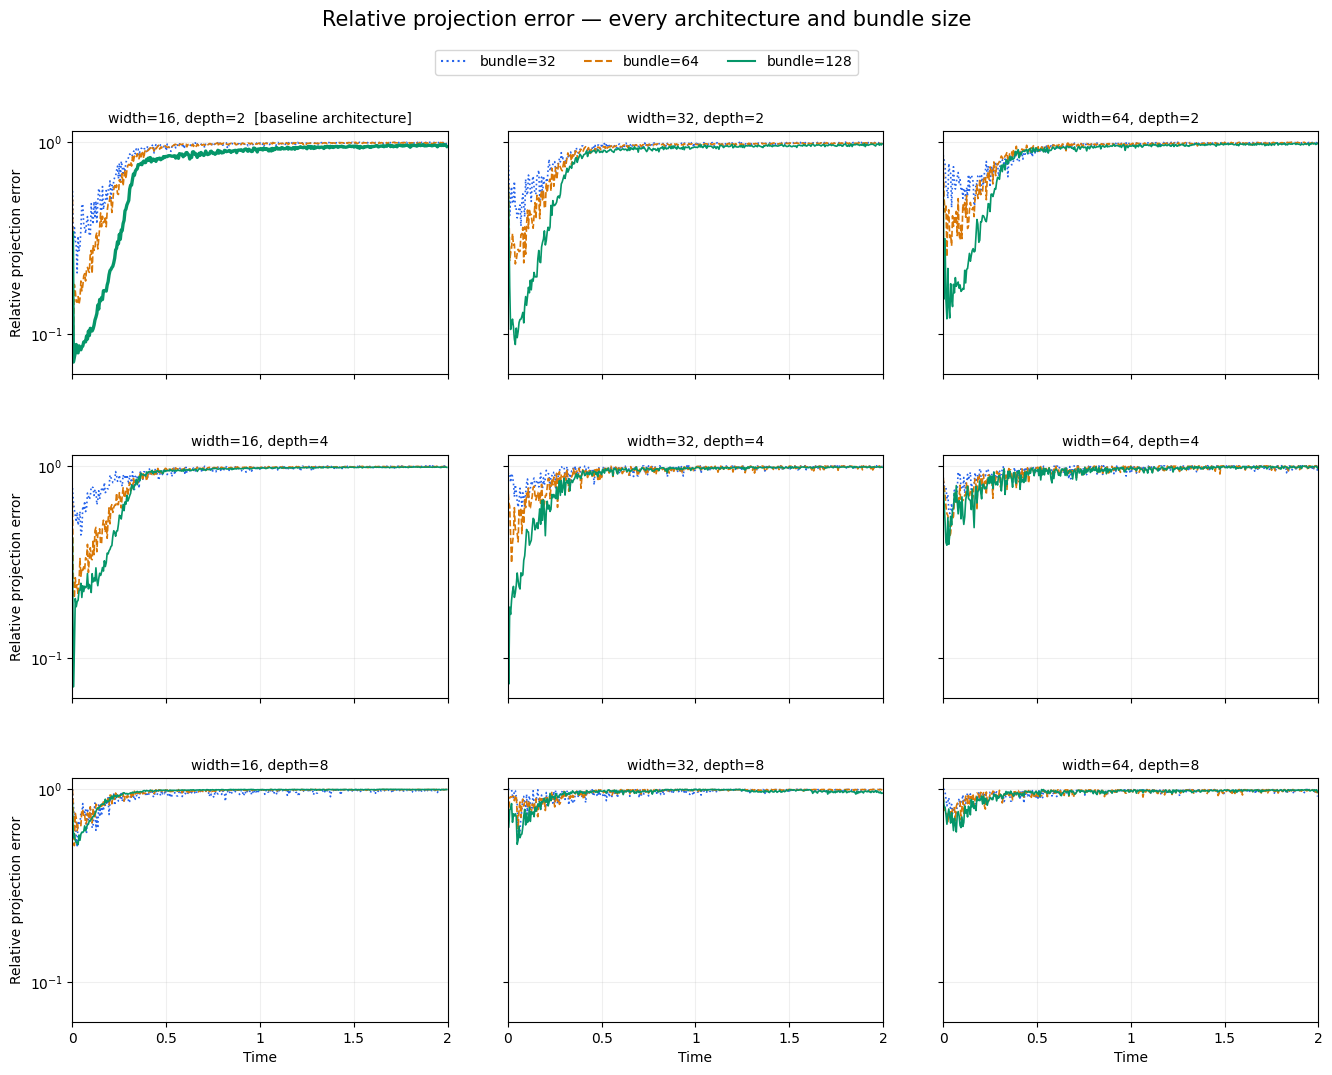

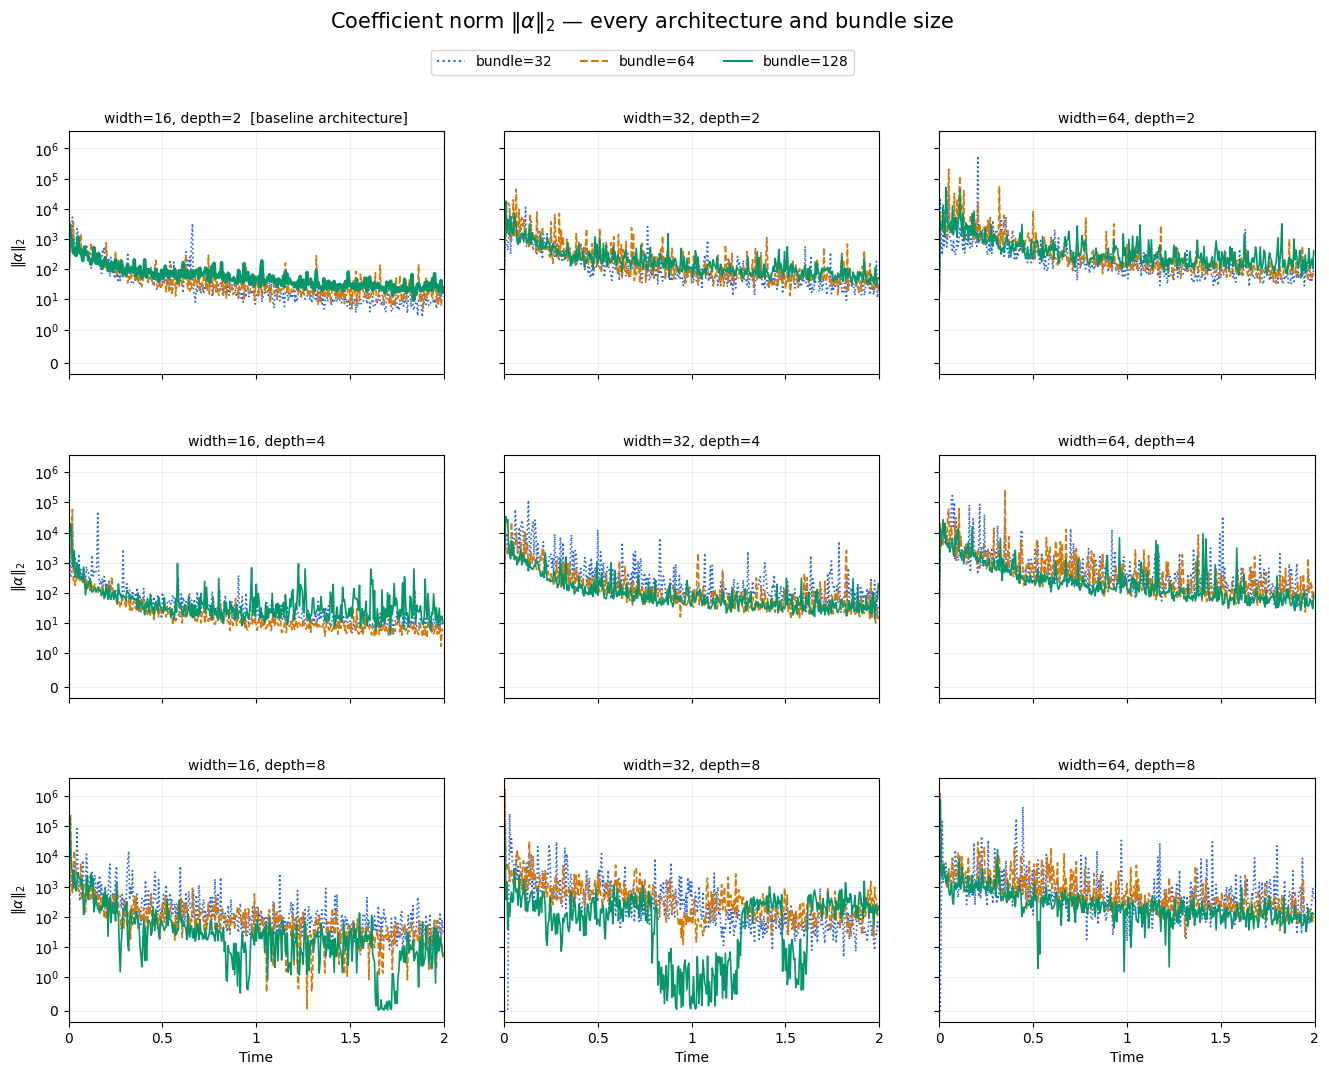

Symlog axes display exact zeros: linear below 1e-5 for relative error and below 1 for alpha norm.


In [9]:
BUNDLE_COLORS = {32: '#2563eb', 64: '#d97706', 128: '#059669'}
BUNDLE_STYLES = {32: ':', 64: '--', 128: '-'}


def architecture_panels(metric, title, ylabel, filename, linear_threshold):
    fig, axes = plt.subplots(len(DEPTHS), len(WIDTHS), figsize=(14, 11),
                             sharex=True, sharey=True, squeeze=False)
    for row, depth in enumerate(DEPTHS):
        for col, width in enumerate(WIDTHS):
            ax = axes[row, col]
            stopped = []
            for bundle in BUNDLE_SIZES:
                config = (width, depth, bundle)
                result = results.get(config)
                if result is None:
                    continue
                data = result['rows']
                ax.plot([r['time'] for r in data], [r[metric] for r in data],
                        color=BUNDLE_COLORS[bundle], linestyle=BUNDLE_STYLES[bundle],
                        linewidth=2.4 if config == BASELINE else 1.2)
                if result['status'] != 'complete':
                    stopped.append(str(bundle))
            ax.set_title(f'width={width}, depth={depth}' + ('  [baseline architecture]' if (width, depth) == BASELINE[:2] else ''), fontsize=10)
            ax.set_xlim(0, T_FINAL)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.xaxis.set_major_formatter(FormatStrFormatter('%.3g'))
            ax.set_yscale('symlog', linthresh=linear_threshold)
            y_locator = SymmetricalLogLocator(base=10, linthresh=linear_threshold)
            y_locator.set_params(numticks=7)
            ax.yaxis.set_major_locator(y_locator)
            ax.grid(alpha=0.2, which='both')
            if row == len(DEPTHS) - 1: ax.set_xlabel('Time')
            if col == 0: ax.set_ylabel(ylabel)
            if stopped: ax.text(.02, .02, 'Stopped bundles: ' + ', '.join(stopped), transform=ax.transAxes, color='#b91c1c', fontsize=8)
    fig.suptitle(title, fontsize=15, y=.99)
    handles = [Line2D([], [], color=BUNDLE_COLORS[m], linestyle=BUNDLE_STYLES[m], label=f'bundle={m}') for m in BUNDLE_SIZES]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(.5, .96), ncol=3)
    fig.subplots_adjust(top=.88, bottom=.07, left=.09, right=.98, hspace=.33, wspace=.16)
    fig.savefig(OUTPUT_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()
    return fig


projection_figure = architecture_panels(
    'relative_projection_error', 'Relative projection error — every architecture and bundle size',
    'Relative projection error', 'relative_projection_error_all_combinations.png', 1e-5,
)
alpha_figure = architecture_panels(
    'alpha_norm', r'Coefficient norm $\|\alpha\|_2$ — every architecture and bundle size',
    r'$\|\alpha\|_2$', 'alpha_norm_all_combinations.png', 1.0,
)
print('Symlog axes display exact zeros: linear below 1e-5 for relative error and below 1 for alpha norm.')

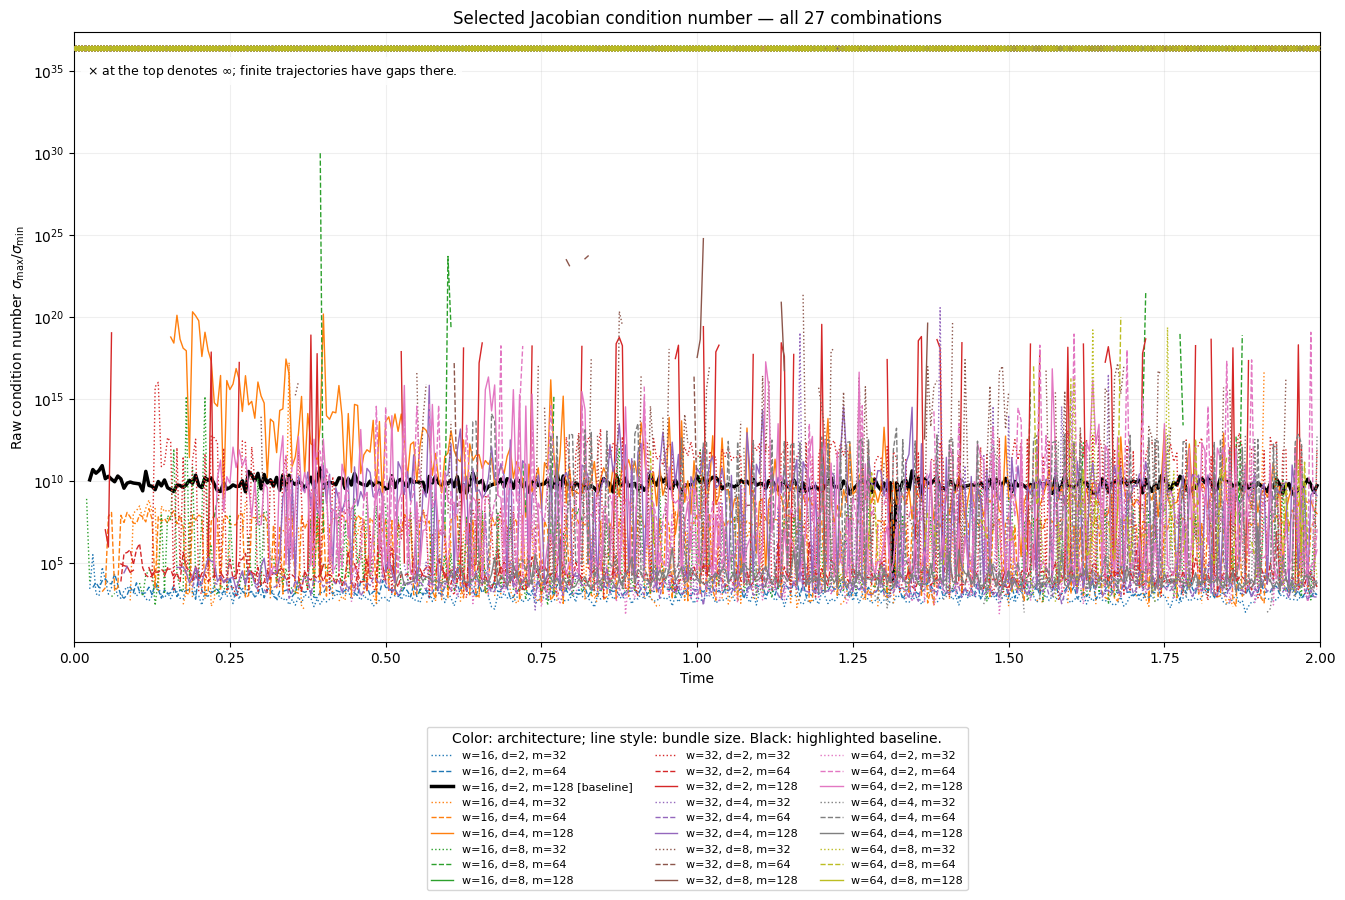

In [10]:
condition_figure, condition_axis = plt.subplots(figsize=(14, 10))
architecture_colors = {arch: plt.get_cmap('tab10')(i) for i, arch in enumerate(product(WIDTHS, DEPTHS))}
has_finite_condition = False
infinite_count = 0
for configuration, result in results.items():
    width, depth, bundle = configuration
    data = result['rows']
    physical_time = np.asarray([r['time'] for r in data])
    values = np.asarray([r['condition_number'] for r in data])
    finite = np.isfinite(values)
    has_finite_condition |= finite.any()
    infinite_count += int(np.isinf(values).sum())
    color = 'black' if configuration == BASELINE else architecture_colors[(width, depth)]
    label = f'w={width}, d={depth}, m={bundle}'
    if configuration == BASELINE: label += ' [baseline]'
    if result['status'] != 'complete': label += ' [stopped]'
    condition_axis.plot(physical_time, np.where(finite, values, np.nan),
                        color=color, linestyle=BUNDLE_STYLES[bundle],
                        linewidth=2.5 if configuration == BASELINE else 1.0, label=label)
    if np.isinf(values).any():
        condition_axis.scatter(physical_time[np.isinf(values)], np.full(np.isinf(values).sum(), .975),
                               transform=condition_axis.get_xaxis_transform(),
                               marker='x', s=12, color=color, alpha=.6, zorder=3)
if not has_finite_condition:
    condition_axis.set_ylim(1, 10)
condition_axis.set_yscale('log')
condition_axis.set(xlabel='Time', ylabel=r'Raw condition number $\sigma_{\max}/\sigma_{\min}$',
                   title='Selected Jacobian condition number — all 27 combinations', xlim=(0, T_FINAL))
condition_axis.grid(alpha=.2, which='both')
if infinite_count:
    condition_axis.text(.01, .93, r'$\times$ at the top denotes $\infty$; finite trajectories have gaps there.',
                        transform=condition_axis.transAxes, fontsize=9,
                        bbox=dict(facecolor='white', alpha=.85, edgecolor='none'))
condition_axis.legend(loc='upper center', bbox_to_anchor=(.5, -.13), ncol=3, fontsize=8,
                      title='Color: architecture; line style: bundle size. Black: highlighted baseline.')
condition_figure.subplots_adjust(bottom=.33, top=.94, left=.09, right=.98)
condition_figure.savefig(OUTPUT_DIR / 'condition_number_all_combinations.png', dpi=200, bbox_inches='tight')
plt.show()

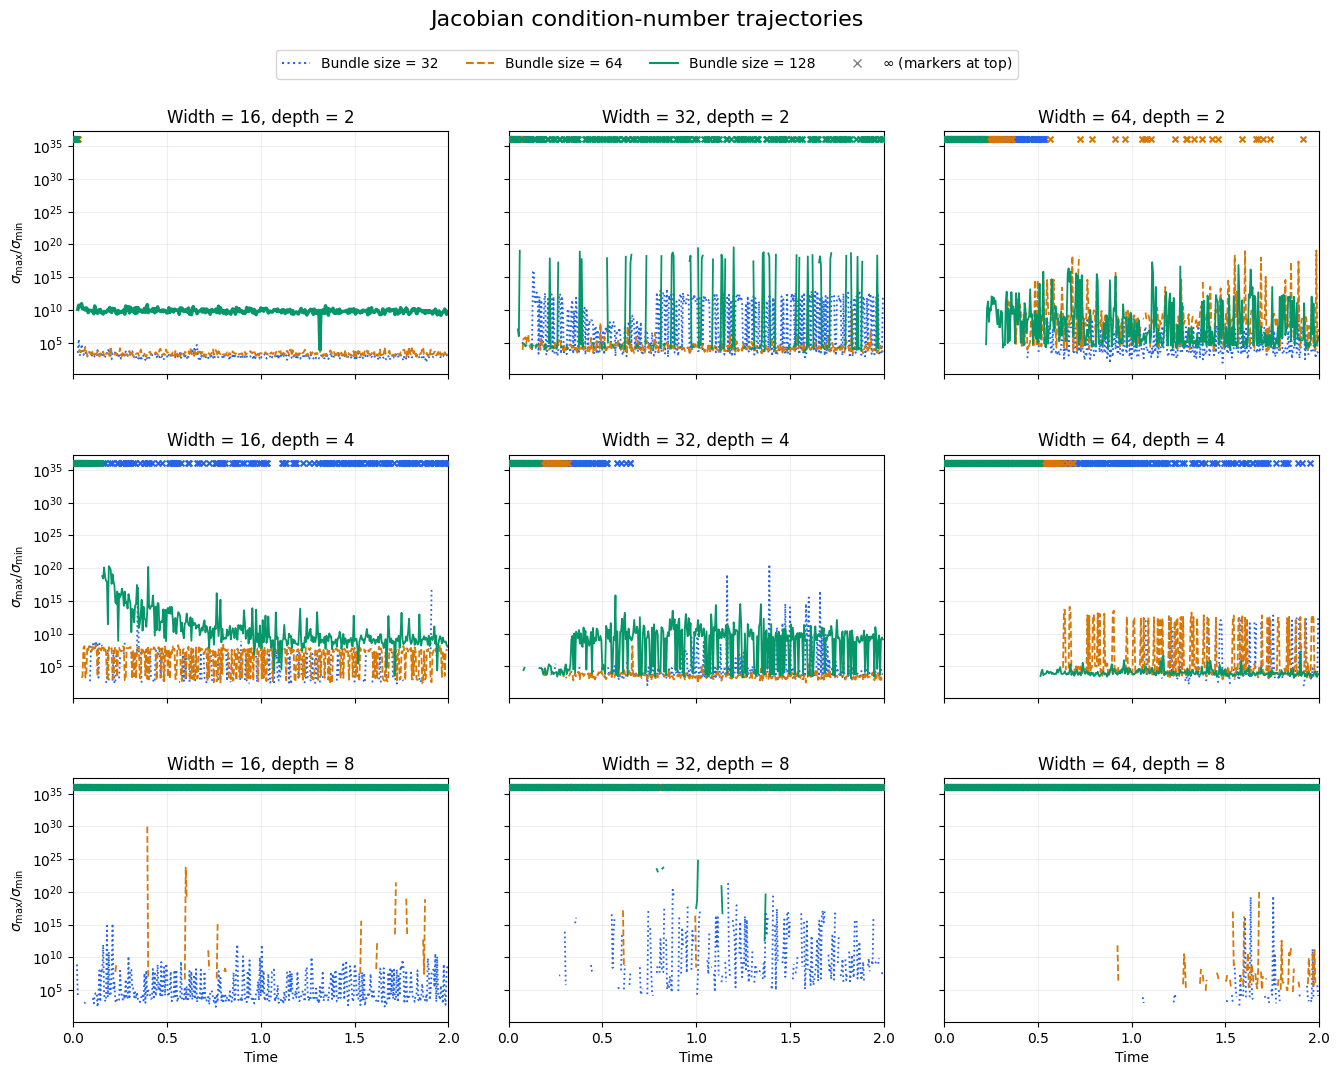

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# Run after the sweep cell that creates `results`.
widths = (16, 32, 64)
depths = (2, 4, 8)
bundles = (32, 64, 128)

colors = {32: "#2563eb", 64: "#d97706", 128: "#059669"}
styles = {32: ":", 64: "--", 128: "-"}

fig, axes = plt.subplots(
    3, 3, figsize=(14, 11),
    sharex=True, sharey=True,
)

any_finite = False
any_infinite = False

for row, depth in enumerate(depths):
    for col, width in enumerate(widths):
        ax = axes[row, col]
        stopped = []

        for bundle in bundles:
            config = (width, depth, bundle)
            result = results.get(config)
            if result is None:
                continue

            data = result["rows"]
            t = np.asarray([r["time"] for r in data])
            condition = np.asarray([r["condition_number"] for r in data])

            finite = np.isfinite(condition)
            infinite = np.isinf(condition)
            any_finite |= finite.any()
            any_infinite |= infinite.any()

            ax.plot(
                t,
                np.where(finite, condition, np.nan),
                color=colors[bundle],
                linestyle=styles[bundle],
                linewidth=2.5 if config == (16, 2, 128) else 1.3,
            )

            # Infinite values are marked at the top, not replaced by a finite value.
            if infinite.any():
                ax.scatter(
                    t[infinite],
                    np.full(infinite.sum(), 0.965),
                    transform=ax.get_xaxis_transform(),
                    color=colors[bundle],
                    marker="x", s=18, zorder=3,
                )

            if result["status"] != "complete":
                stopped.append(str(bundle))

        ax.set_title(f"Width = {width}, depth = {depth}")
        ax.set_xlim(0, T_FINAL)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.grid(alpha=0.2, which="both")

        if row == 2:
            ax.set_xlabel("Time")
        if col == 0:
            ax.set_ylabel(r"$\sigma_{\max}/\sigma_{\min}$")

        if stopped:
            ax.text(
                0.02, 0.02, "Stopped bundles: " + ", ".join(stopped),
                transform=ax.transAxes, color="red", fontsize=8,
            )

# Shared logarithmic scale across all nine panels.
if not any_finite:
    axes[0, 0].set_ylim(1, 10)
axes[0, 0].set_yscale("log")

handles = [
    Line2D(
        [], [], color=colors[m], linestyle=styles[m],
        label=f"Bundle size = {m}",
    )
    for m in bundles
]
if any_infinite:
    handles.append(
        Line2D(
            [], [], color="gray", marker="x", linestyle="None",
            label=r"$\infty$ (markers at top)",
        )
    )

fig.suptitle("Jacobian condition-number trajectories", fontsize=16, y=0.99)
fig.legend(
    handles=handles, loc="upper center",
    bbox_to_anchor=(0.5, 0.96), ncol=len(handles),
)
fig.subplots_adjust(
    top=0.88, bottom=0.07, left=0.09, right=0.98,
    hspace=0.33, wspace=0.16,
)

fig.savefig(
    OUTPUT_DIR / "condition_number_by_architecture.png",
    dpi=200, bbox_inches="tight",
)
plt.show()

## Is the error caused by the numerical solver?

Inspect `sweep_summary.csv` and each `*_solver_audit.csv` together with the three figures.

- **Large projection error, tiny reconstruction discrepancy, and CPU prediction agreement:** the chosen truncated tangent space does not represent the velocity well; these checks do not implicate least-squares arithmetic.
- **Large changes as `rtol` changes:** the singular-value cutoff materially affects the projection. Lowering it may improve the residual while greatly increasing $\|\alpha\|$ and the parameter step. The audits change only the frozen linear solve; they do not establish that the resulting full trajectory would be better.
- **CPU and main solver predictions disagree:** inspect the retained ranks first. A singular value close to the cutoff can change the retained rank. Agreement of predictions is more meaningful than agreement of coefficients for an ill-conditioned system.
- **Huge raw condition number, modest effective condition number:** ill-conditioned directions may have been discarded intentionally. Do not infer solver failure from the raw ratio alone.
- **Few initially active columns or rank zero in deeper/wider models:** this is a consequence of zero-output initialization combined with random coordinate selection. The selection fraction and initial active count are saved for every run.
- **Small projection error but large error versus direct Euler:** also inspect time discretization and the accumulated parameter updates. The reference is numerical, not an exact solution. The optional experiment below compares $H$ with $H/2$ while holding the coordinate-selection schedule fixed over each coarse step.

No claim that width 16 / depth 2 / bundle 128 is best is hard-coded. The notebook highlights that configuration so your observed trend can be checked against the other 26 runs.

In [14]:
if RUN_BASELINE_STEP_CHECK:
    coarse = results.get(BASELINE)
    if coarse is None or coarse['status'] != 'complete':
        print('The baseline must finish successfully before the step-size check.')
    else:
        fine = run_case(*BASELINE, refinement=2, enable_audit=False)
        if fine['status'] == 'complete':
            dtb_step_rms = np.sqrt(np.mean(np.sum((coarse['final_x'] - fine['final_x']) ** 2, axis=1)))
            fine_reference = euler_reference(z, refine_grid(base_times, 2))
            euler_step_rms = (reference[-1] - fine_reference[-1]).square().sum(1).mean().sqrt().item()
            step_check = dict(baseline=BASELINE, coarse_h=H, fine_h=H/2,
                              dtb_final_rms_difference=dtb_step_rms,
                              euler_final_rms_difference=euler_step_rms,
                              selection_schedule='same coordinates for both half steps within each coarse interval')
            (OUTPUT_DIR / 'baseline_step_halving.json').write_text(json.dumps(step_check, indent=2))
            print(json.dumps(step_check, indent=2))
        else:
            print('The refined baseline failed:', fine['failure'])
else:
    print('Optional: set RUN_BASELINE_STEP_CHECK=True and rerun this cell for an H/2 baseline test.')

Optional: set RUN_BASELINE_STEP_CHECK=True and rerun this cell for an H/2 baseline test.


In [15]:
archive = shutil.make_archive(str(OUTPUT_DIR), 'zip', root_dir=OUTPUT_DIR)
print('All figures, run diagnostics, solver audits, reference data, and settings:', archive)
try:
    from google.colab import files
except ImportError:
    print('Local run: open the ZIP path above.')
else:
    files.download(archive)

All figures, run diagnostics, solver audits, reference data, and settings: /content/cournot_mlp_sweep_seed0_20260910-020027.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>